# Seu trajectory analysis

this notebook reconstructs and analyses trajectories for a rolling robot prototype (seu).  
the pipeline:

1. load or track trajectories from raw videos  
2. save a clean trial-level trajectory table  
3. compute summary features per trial (velocity, acceleration, displacement, directional bias, etc.)  
4. aggregate features by physical configuration (mass position, wheel orientation, starting side)  
5. visualise trajectories and feature distributions for flat vs incline conditions

## 1. Extract x–y trajectories from raw experiment videos
### Configuration and imports

this section defines global configuration parameters (fps, scale, file locations)  
and loads all required python packages.  

the notebook also loads custom helper modules from the `../code/` directory:
- `extract_trajectory.py` → handles video tracking and bounding-box extraction
- `compute_features.py` → computes trial-level kinematic features
- `estimate_kappa.py` → implements curvature estimation utilities

autoreload is enabled so that changes to these modules are picked up automatically.

In [1]:
# configuration

USE_SAVED = True
FPS = 60
SCALE = 0.17

TRAJECTORY_PATH = "../data/trajectories/all_trials.csv"
FEATURE_PATH = "../data/features/features.csv"

In [2]:
# imports and helper modules

%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../code")

from extract_trajectory import select_bbox, process_folder
from compute_features import summarize_all_trials
from estimate_kappa import estimate_kappa_gridsearch, estimate_kappa_from_heading

### Loading or tracking trajectories

the analysis can run in two modes:

- **use_saved = true** → load a precomputed trajectory table  
- **use_saved = false** → track trajectories from the raw videos

the tracking pipeline performs:
1. bounding-box selection for the region of interest  
2. per-frame detection of the robot  
3. smoothing + trial segmentation  
4. attaching metadata:  
   - `condition` (flat / incline)  
   - `orientation` (wheel orientation or starting side)  
   - `position` (front or rear weighting of the mass block)

the resulting dataframe (`all_traj`) contains one row per frame.

In [23]:
# load OR track

if USE_SAVED and os.path.exists(TRAJECTORY_PATH):
    print("loading saved trajectory data...")
    all_traj = pd.read_csv(TRAJECTORY_PATH)
    print("loaded:", all_traj.shape)
else:
    print("tracking videos...")
    base_video_dir = "../data/videos"
    all_dataframes = []

    for condition in ["flat", "incline"]:
        condition_path = os.path.join(base_video_dir, condition)
        for orientation in os.listdir(condition_path):
            if orientation.startswith("."):
                continue
            folder = os.path.join(condition_path, orientation)
            if not os.path.isdir(folder):
                continue

            print(f"tracking: {folder}")
            try:
                bbox = select_bbox(folder, label=f"{condition}-{orientation}")
                if bbox == (0, 0, 0, 0):
                    raise ValueError("empty roi selected")
            except Exception as e:
                print(f"skipping {folder} — error: {e}")
                continue

            df = process_folder(folder, bbox)
            if not df.empty:
                df["condition"] = condition          # flat / incline
                df["orientation"] = orientation       # wheels or side, depending on condition
                all_dataframes.append(df)

    if all_dataframes:
        all_traj = pd.concat(all_dataframes, ignore_index=True)
        os.makedirs(os.path.dirname(TRAJECTORY_PATH), exist_ok=True)
        all_traj.to_csv(TRAJECTORY_PATH, index=False)
        print("saved:", TRAJECTORY_PATH)
    else:
        raise RuntimeError("no trajectory data collected")
all_traj

loading saved trajectory data...
loaded: (35501, 7)


,trial,position,orientation,frame,x,y,condition
0,flipped_back (1),back,flipped,0,1810.0,543.0,flat
1,flipped_back (1),back,flipped,1,1810.0,543.0,flat
2,flipped_back (1),back,flipped,2,1810.0,543.0,flat
3,flipped_back (1),back,flipped,3,1810.0,544.0,flat
4,flipped_back (1),back,flipped,4,1811.0,544.0,flat
...,...,...,...,...,...,...,...
35496,right_front (9),front,right,217,797.0,339.0,incline
35497,right_front (9),front,right,218,797.0,339.0,incline
35498,right_front (9),front,right,219,797.0,340.0,incline
35499,right_front (9),front,right,220,798.0,340.0,incline


### Splitting into flat vs incline conditions

after loading, trajectories are separated into:
- **flat_traj**: robot rolling on a flat surface  
- **incline_traj**: robot rolling uphill on a fixed incline

additional label dictionaries are defined to make plots readable  
(e.g., `wheels: normal` → normal wheel orientation).

In [4]:
# split flat vs incline and define label dictionaries

flat_df = all_traj[all_traj["condition"] == "flat"].copy()
incline_df = all_traj[all_traj["condition"] == "incline"].copy()

mass_label = {
    "front": "mass: front",
    "back": "mass: rear",
}

wheel_label = {
    "normal": "wheels: normal",
    "flipped": "wheels: flipped",
}

side_label = {
    "left": "starts: left",
    "right": "starts: right",
}

## 2. Trajectory visualizations

this section visualizes raw x–y trajectories to understand behavior differences under:
- different mass placements (front / back)
- different wheel orientations (normal / flipped)
- different starting sides on the incline (left / right)

plots are grouped into:
1. **flat: wheel × mass (2×2 grid)**  
2. **flat: grouped by mass**  
3. **flat: grouped by wheel orientation**  
4. **incline: starting side × mass (2×2 grid)**  

this allows a quick qualitative check of:
- whether the robot rolls consistently  
- whether the mass / wheel configuration systematically changes the path shape  
- whether incline trials show clear directional preferences

#### 2.1 Flat condition – 2x2 grid by wheel orientation and mass position

here we group `flat_df` by `(orientation, position)` and visualize four configurations:

1. normal wheels + rear mass  
2. normal wheels + front mass  
3. flipped wheels + rear mass  
4. flipped wheels + front mass  

each panel shows all trials for that configuration, with fixed axis limits, inverted y-axis and equal aspect ratio so the shapes are directly comparable.


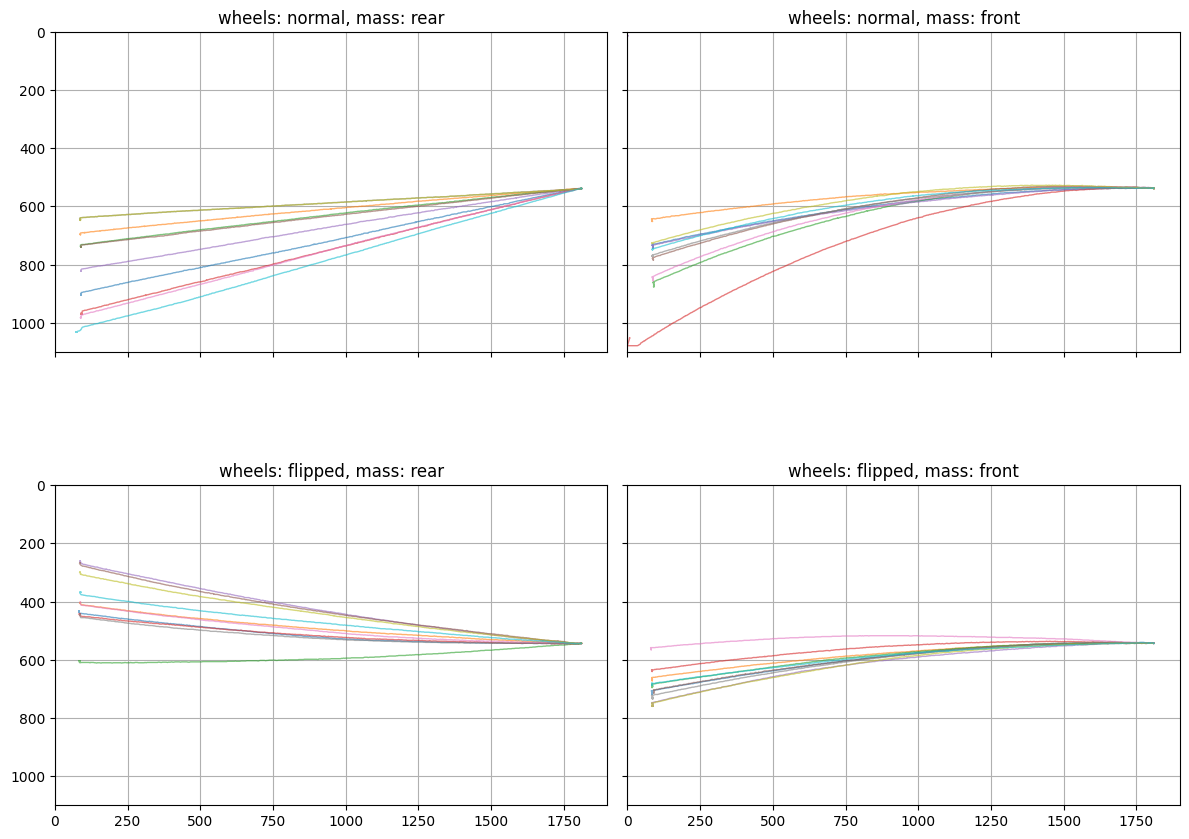

In [5]:
# flat condition: 2x2 grid by wheel orientation and mass position

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

groups = flat_df.groupby(["orientation", "position"])

# consistent order
keys = [
    ("normal", "back"),
    ("normal", "front"),
    ("flipped", "back"),
    ("flipped", "front"),
]

for ax, key in zip(axes, keys):
    orientation, position = key
    label_w = wheel_label[orientation]
    label_m = mass_label[position]
    group_df = groups.get_group(key)

    for trial_id, trial_df in group_df.groupby("trial"):
        ax.plot(trial_df["x"], trial_df["y"], alpha=0.6, linewidth=1)

    ax.set_title(f"{label_w}, {label_m}")
    ax.set_xlim(0, 1900)
    ax.set_ylim(0, 1100)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.grid(True)

plt.tight_layout()
plt.show()

#### Flat condition – grouped views by mass and wheels

to better isolate individual factors, we replot the same trajectories in two ways:

- **2.2 grouped by mass position**  
  - left: mass at the front  
  - right: mass at the rear  
  - within each panel, trajectories are colored by wheel configuration

- **2.3 grouped by wheel orientation**  
  - left: normal wheels  
  - right: flipped wheels  
  - within each panel, trajectories are colored by mass position

these plots highlight how changing one design choice (mass or wheels) affects the motion while holding the other fixed.

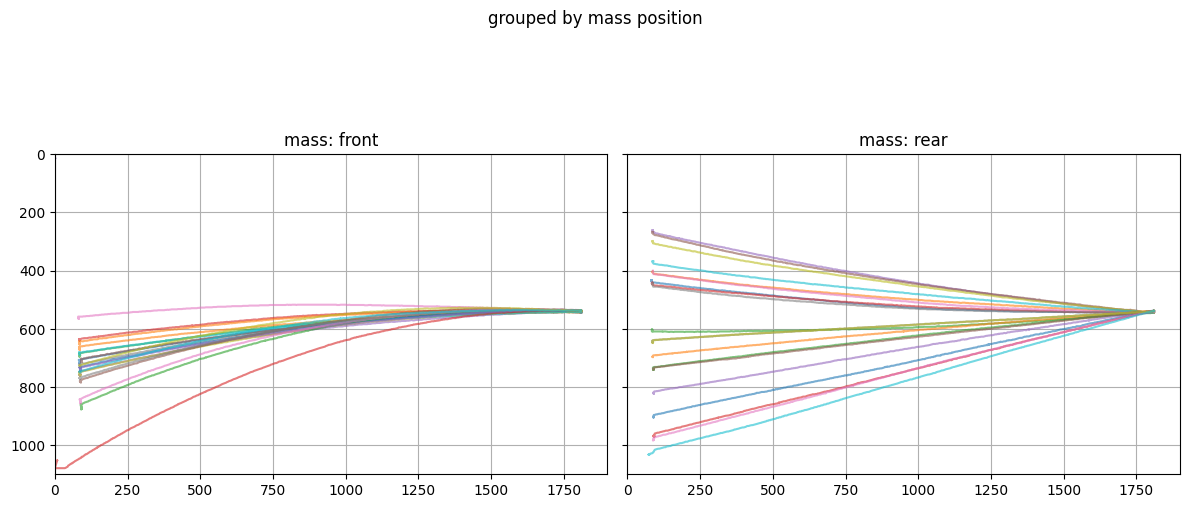

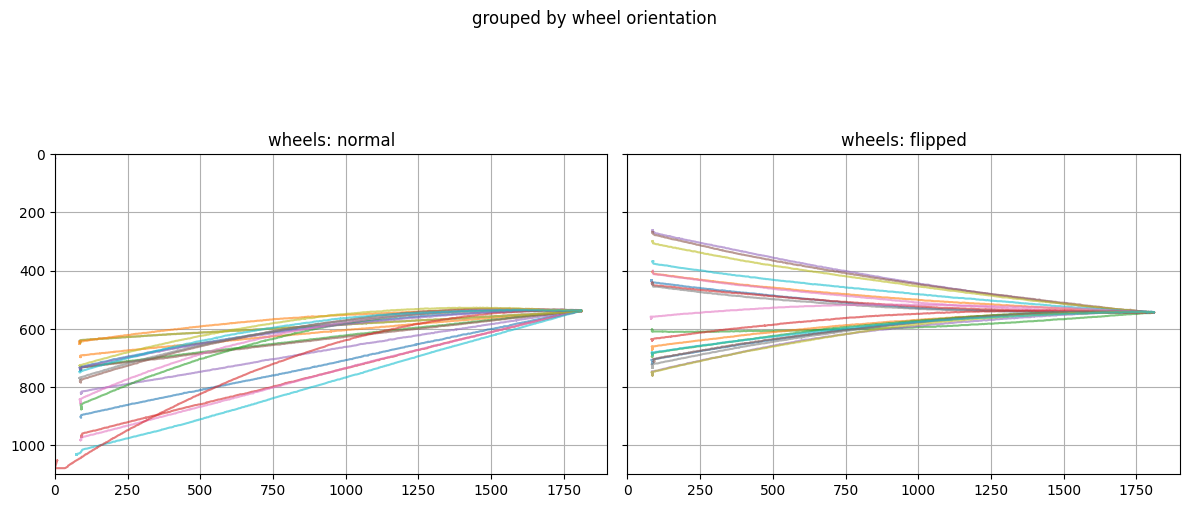

In [11]:
# flat condition: grouped by mass position

fig1, axes1 = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

for ax, mass in zip(axes1, ["front", "back"]):
    subset = flat_df[flat_df["position"] == mass]
    for (orientation, trial_id), trial_df in subset.groupby(["orientation", "trial"]):
        ax.plot(trial_df["x"], trial_df["y"], label=wheel_label[orientation], alpha=0.6)
    ax.set_title(mass_label[mass])
    ax.set_xlim(0, 1900)
    ax.set_ylim(0, 1100)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.grid(True)

fig1.suptitle("grouped by mass position")
plt.tight_layout()
plt.show()

# flat condition: grouped by wheel orientation

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

for ax, orientation in zip(axes2, ["normal", "flipped"]):
    subset = flat_df[flat_df["orientation"] == orientation]
    for (position, trial_id), trial_df in subset.groupby(["position", "trial"]):
        ax.plot(trial_df["x"], trial_df["y"], label=mass_label[position], alpha=0.6)
    ax.set_title(wheel_label[orientation])
    ax.set_xlim(0, 1900)
    ax.set_ylim(0, 1100)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.grid(True)

fig2.suptitle("grouped by wheel orientation")
plt.tight_layout()
plt.show()

#### 2.4 Incline condition – trajectories by mass and starting side

for the incline condition, we group trajectories by:

- `position`: mass at the front vs mass at the rear.
- `orientation`: whether the robot starts on the left or right side of the incline.

we create a 2x2 grid of subplots, one per combination present in the data. within each panel:

- each line corresponds to a single trial's trajectory.
- we keep axis limits and aspect ratio fixed so that panels are comparable.

this view shows how mass placement and starting side affect the robot's ability to climb or reorient on the incline.

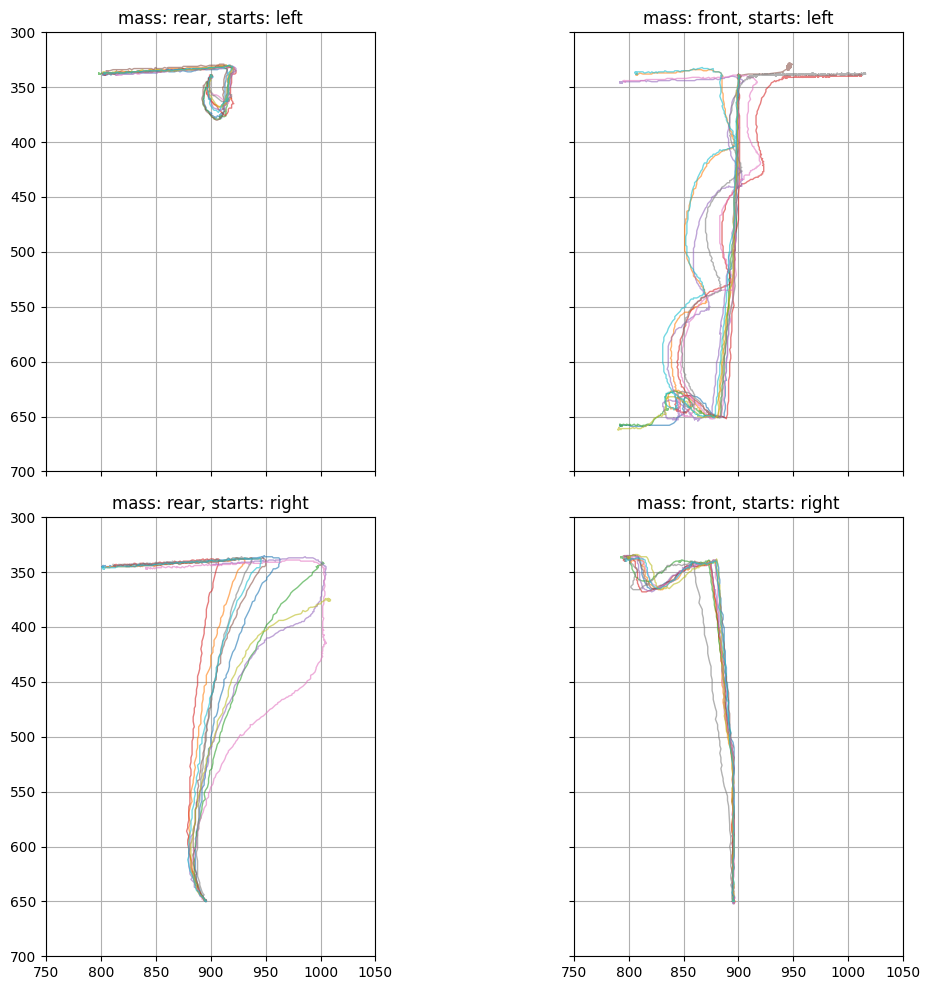

In [7]:
# incline condition: trajectories by mass placement and starting side

groups = incline_df.groupby(["orientation", "position"])
group_keys = sorted(groups.groups.keys())

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, key in zip(axes, group_keys):
    orientation, position = key
    label_s = side_label.get(orientation, orientation)
    label_m = mass_label.get(position, position)
    group_df = groups.get_group(key)

    for trial_id, trial_df in group_df.groupby("trial"):
        ax.plot(trial_df["x"], trial_df["y"], alpha=0.6, linewidth=1)

    ax.set_title(f"{label_m}, {label_s}")
    ax.set_xlim(750, 1050)
    ax.set_ylim(700, 300)
    ax.set_aspect("equal")
    ax.grid(True)

for ax in axes[len(group_keys):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Trial-level feature extraction

in this step we reduce each trajectory to a compact set of trial-level features using `summarize_all_trials()`.

for each trial we compute, among others:

- velocity features (mean, variability)
- acceleration features (mean, variability, startup acceleration)
- displacement and path length
- directional bias (net x-shift along the incline axis)
- optional curvature-related summaries

the output is saved to `data/features/features.csv` for reuse.

In [19]:
features_df = summarize_all_trials(all_traj, fps=FPS, scale=SCALE)

os.makedirs(os.path.dirname(FEATURE_PATH), exist_ok=True)
features_df.to_csv(FEATURE_PATH, index=False)

print("features saved:", FEATURE_PATH)
print("feature table shape:", features_df.shape)

features_df.head()

features saved: ../data/features/features.csv
feature table shape: (80, 10)


,trial,position,orientation,mean_velocity,std_velocity,mean_acceleration,std_acceleration,startup_acceleration,displacement,directional_bias
0,flipped_back (1),back,flipped,34.921967,15.888494,0.012363,3.434817,10.2,294.015283,-18.70
1,flipped_back (10),back,flipped,35.019732,14.665795,0.000000,2.827193,10.2,293.692159,-23.63
2,flipped_back (2),back,flipped,36.341045,13.004079,0.020336,2.940684,10.2,293.427338,10.20
3,flipped_back (3),back,flipped,34.060252,15.551303,0.018768,3.126853,10.2,293.752228,-17.17
4,flipped_back (4),back,flipped,35.393250,15.559325,0.001180,3.959934,10.2,296.807196,-47.94


### Attaching trial-level metadata

the feature table already stores `position` and `orientation` per trial
(from `summarize_all_trials`). here we only merge in the `condition` label
(flat vs incline) from the full trajectory table.

this keeps a single, clean copy of:
- `trial`
- `condition`
- `position`
- `orientation`
for each trial in `features_df`.

In [20]:
# attach trial-level metadata: condition, position, orientation

meta = (
    all_traj[["trial", "condition"]]
    .drop_duplicates()
)

features_df = pd.merge(features_df, meta, on="trial", how="left")

# features_df[["trial", "condition", "position", "orientation"]].drop_duplicates().head()
features_df.head()

,trial,position,orientation,mean_velocity,std_velocity,mean_acceleration,std_acceleration,startup_acceleration,displacement,directional_bias,condition
0,flipped_back (1),back,flipped,34.921967,15.888494,0.012363,3.434817,10.2,294.015283,-18.70,flat
1,flipped_back (10),back,flipped,35.019732,14.665795,0.000000,2.827193,10.2,293.692159,-23.63,flat
2,flipped_back (2),back,flipped,36.341045,13.004079,0.020336,2.940684,10.2,293.427338,10.20,flat
3,flipped_back (3),back,flipped,34.060252,15.551303,0.018768,3.126853,10.2,293.752228,-17.17,flat
4,flipped_back (4),back,flipped,35.393250,15.559325,0.001180,3.959934,10.2,296.807196,-47.94,flat


## 4. Aggregated feature summaries

here we aggregate the trial-level features by mechanical configuration:

- **position**: front vs back mass
- **orientation**: wheel orientation or starting side
- **condition**: flat vs incline

the resulting dataframes `group_summary_flat` and `group_summary_incline` contain, for each configuration, the mean and standard deviation of each feature across trials (e.g. `mean_velocity_mean`, `mean_velocity_std`, etc.).

we then plot these aggregated statistics to see how the configuration affects:
- speed
- startup acceleration
- displacement
- directional bias


In [21]:
# summary statistics for flat trials

flat_feat = features_df[features_df["condition"] == "flat"].copy()
assert flat_feat.shape[0] > 0, "no flat trials found"

numeric_cols_flat = flat_feat.select_dtypes(include="number").columns

grouped_summary_flat = (
    flat_feat
    .groupby(["position", "orientation"])[numeric_cols_flat]
    .agg(["mean", "std"])
)

grouped_summary_flat.columns = ["_".join(col) for col in grouped_summary_flat.columns]
grouped_summary_flat = grouped_summary_flat.reset_index()

grouped_summary_flat.round(3)

,position,orientation,mean_velocity_mean,mean_velocity_std,std_velocity_mean,std_velocity_std,mean_acceleration_mean,mean_acceleration_std,std_acceleration_mean,std_acceleration_std,startup_acceleration_mean,startup_acceleration_std,displacement_mean,displacement_std,directional_bias_mean,directional_bias_std
0,back,flipped,35.089,0.823,15.106,0.860,0.005,0.010,3.243,0.540,10.200,0.000,294.576,1.371,-25.670,17.371
1,back,normal,33.017,1.074,14.360,1.540,0.008,0.012,3.146,0.675,11.467,2.041,297.515,4.601,47.566,24.593
2,front,flipped,31.469,1.219,17.687,1.242,-0.000,0.013,3.261,0.385,10.200,0.000,294.384,0.644,25.602,10.047
3,front,normal,33.883,5.009,45.998,95.461,0.008,0.019,14.239,34.658,10.200,0.000,300.381,10.080,30.753,45.892


In [22]:
# summary statistics for incline trials

incline_feat = features_df[features_df["condition"] == "incline"].copy()
assert incline_feat.shape[0] > 0, "no incline trials found"

numeric_cols_incline = incline_feat.select_dtypes(include="number").columns

grouped_summary_incline = (
    incline_feat
    .groupby(["position", "orientation"])[numeric_cols_incline]
    .agg(["mean", "std"])
)

grouped_summary_incline.columns = ["_".join(col) for col in grouped_summary_incline.columns]
grouped_summary_incline = grouped_summary_incline.reset_index()

grouped_summary_incline.round(3)

,position,orientation,mean_velocity_mean,mean_velocity_std,std_velocity_mean,std_velocity_std,mean_acceleration_mean,mean_acceleration_std,std_acceleration_mean,std_acceleration_std,startup_acceleration_mean,startup_acceleration_std,displacement_mean,displacement_std,directional_bias_mean,directional_bias_std
0,back,left,14.754,1.134,11.573,0.917,0.017,0.034,2.947,0.348,10.622,1.336,15.983,0.854,-0.221,0.197
1,back,right,20.429,2.741,14.331,1.641,0.030,0.029,2.507,0.367,12.487,3.420,53.189,1.379,-51.204,1.705
2,front,left,15.913,5.413,14.974,2.761,0.008,0.010,2.770,0.357,11.890,2.182,28.638,20.106,16.320,26.289
3,front,right,22.355,1.582,18.151,0.800,0.025,0.031,3.406,0.569,11.045,1.781,55.289,0.305,-52.819,0.278


In [ ]:
## feature visualisation

in this section, we visualise the trial-level features extracted from the trajectories.
we focus on four key summary measures:

- mean velocity
- startup acceleration
- displacement
- directional bias

these are shown across different mechanical configurations (mass position and orientation) and, where relevant, across flat vs incline conditions.


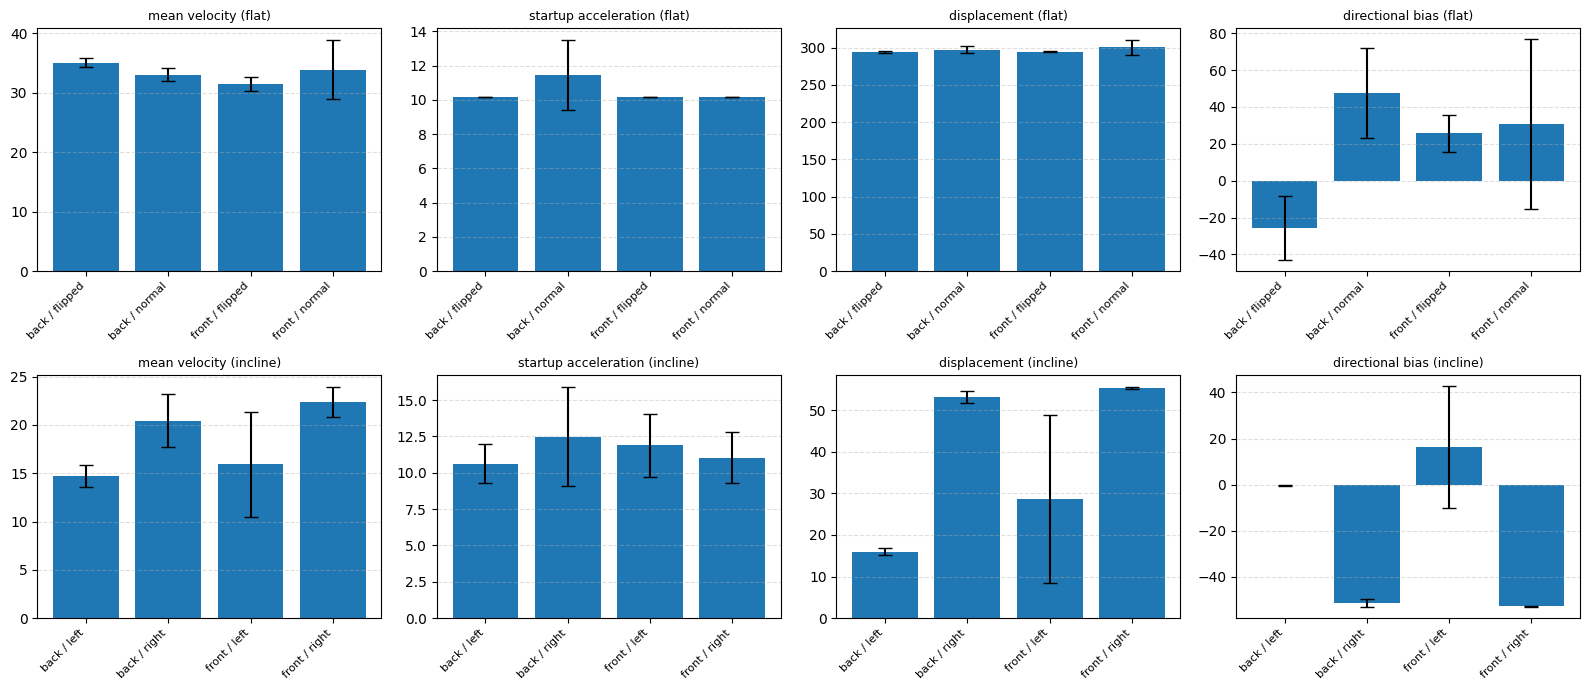

In [28]:
# make copies so we do not modify originals
flat_summary = grouped_summary_flat.copy()
incline_summary = grouped_summary_incline.copy()

# add a compact config label to each summary
flat_summary["config"] = flat_summary["position"].astype(str) + " / " + flat_summary["orientation"].astype(str)
incline_summary["config"] = incline_summary["position"].astype(str) + " / " + incline_summary["orientation"].astype(str)

# dictionary of condition -> df
summary_by_condition = {
    "flat": flat_summary,
    "incline": incline_summary,
}

# list of (mean_col, std_col, nice_label)
feature_specs = [
    ("mean_velocity_mean", "mean_velocity_std", "mean velocity"),
    ("startup_acceleration_mean", "startup_acceleration_std", "startup acceleration"),
    ("displacement_mean", "displacement_std", "displacement"),
    ("directional_bias_mean", "directional_bias_std", "directional bias"),
]

n_conditions = len(summary_by_condition)
n_features = len(feature_specs)

fig, axes = plt.subplots(
    n_conditions,
    n_features,
    figsize=(4 * n_features, 3.5 * n_conditions),
    sharey=False,
)

# ensure axes is 2d even if shapes collapse
if n_conditions == 1:
    axes = np.expand_dims(axes, axis=0)
if n_features == 1:
    axes = np.expand_dims(axes, axis=1)

for row_idx, (condition, df) in enumerate(summary_by_condition.items()):
    # get config order for this condition
    config_order = df["config"].tolist()
    x = np.arange(len(config_order))

    for col_idx, (mean_col, std_col, label) in enumerate(feature_specs):
        ax = axes[row_idx, col_idx]

        means = df.set_index("config")[mean_col].reindex(config_order)
        stds = df.set_index("config")[std_col].reindex(config_order)

        ax.bar(x, means.values, yerr=stds.values, capsize=5)
        ax.set_xticks(x)
        ax.set_xticklabels(config_order, rotation=45, ha="right", fontsize=8)
        ax.set_title(f"{label} ({condition})", fontsize=9)
        ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Conclusion & deliverables

in this notebook, we reconstructed the full analysis pipeline used in the SEU rolling robot experiments and produced clean, reproducible outputs. the workflow takes raw video recordings, extracts structured trajectories, computes quantitative features for each trial, and generates visual and statistical summaries for both flat and incline conditions.

### **1. Trial tajectory data**
the full set of extracted trajectories has been saved to: `data/trajectories/all_trials.csv`

this dataset contains:
- x position
- y position
- frame nr.
- trial number
- wheel orientation (normal / flipped)
- mass position (front / back)
- condition labels (flat / incline)

these files are kept to preserve reproducibility and allow re-processing without rerunning tracking.

### **2. Feature level dataset**
trial-level summary features were computed using `summarize_all_trials()` and saved to: `data/features/features.csv`

each row in this table represents a single trial and contains:

### velocity statistics
- `mean_velocity_mean`
- `mean_velocity_std`
- `std_velocity_mean`
- `std_velocity_std`  
these describe the robot’s average speed and variability across the trial.

### acceleration statistics
- `mean_acceleration_mean`
- `mean_acceleration_std`
- `std_acceleration_mean`
- `std_acceleration_std`  
summarizing the robot’s acceleration profile over time.

### startup acceleration
- `startup_acceleration_mean`
- `startup_acceleration_std`  
capturing how strongly the robot initiates movement in the first frames.

### trajectory displacement
- `displacement_mean`
- `displacement_std`  
quantifying how far the robot traveled from its starting location.

### directional bias
- `directional_bias_mean`
- `directional_bias_std`  
indicating whether the robot consistently veered left/right or uphill/downhill.

### experimental metadata
- `position` (mass front/back)
- `orientation` (wheel normal/flipped or left/right for incline)
- `condition` (flat or incline)  
these identify the physical configuration used in each trial.

## 5. Conclusion

in this notebook we:

- reconstructed trial-level trajectories for all recorded runs and saved them to `data/trajectories/all_trials.csv`
- computed summary features per trial and saved them to `data/features/features.csv`
- aggregated these features by mechanical configuration into `group_summary_flat` and `group_summary_incline`
- visualised both raw trajectories and feature distributions for flat and incline conditions

qualitatively, the analysis shows:

- **flat condition**:  
  - moving the mass to the back and flipping the wheels tends to increase displacement and mean velocity.  
  - front/back mass shifts and wheel orientation both leave a clear footprint on path shape.

- **incline condition**:  
  - some configurations show strong directional bias (large positive or negative values), indicating a consistent tendency to drift up or down the slope.  
  - displacement and startup acceleration distinguish “strong climbers” from “weak” ones.

these results illustrate how the mechanical design (mass placement, wheel orientation, starting side) can be used to engineer directional behaviour into a rolling robot, even with minimal onboard computation.
